In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [3]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

In [4]:
data_rf = yf.download('^TYX', start=start_date, end=end_date, interval='1mo')
rf_annual_pct = data_rf["Close"].mean()
rf = float(rf_annual_pct / 100) 
rf = (1 + rf)**(1/12) - 1                   

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_28832\377976602.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf = float(rf_annual_pct / 100)


In [5]:
portfolio = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()
for ticker in portfolio:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
print(returns_df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2019-08-01 -0.022714 -0.066222 -0.048474 -0.046226 -0.079075 -0.000898   
2019-09-01  0.025711  0.067639 -0.022733  0.071273  0.043925  0.115943   
2019-10-01  0.030840  0.307427  0.023475  0.061433 -0.043053  0.054545   
2019-11-01  0.035979  0.047695  0.013587  0.063204  0.008288  0.033019   
2019-12-01  0.027069  0.267897  0.026122  0.057984  0.036570  0.098312   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2019-08-01 -0.020673 -0.081220  0.079123 -0.045110  
2019-09-01 -0.023201  0.080264 -0.033948 -0.138806  
2019-10-01  0.039133  0.052214  0.025635  0.109203  
2019-11-01  0.050899  0.132908 -0.032086 -0.177177  
2019-12-01 -0.016224 -0.004952  0.036559 -0.049676  


In [6]:
statistics_df = pd.DataFrame({
    'Expected Return': returns_df.mean(),          
    'Variance': returns_df.var(),                  
    'Standard Deviation': returns_df.std()         
})

# Rinomina l'indice
statistics_df.index.name = 'Ticker'
statistics_df = statistics_df.round(4)
print("\nPortfolio Statistics:")
print(statistics_df)


Portfolio Statistics:
         Expected Return  Variance  Standard Deviation
Ticker                                                
GOOGL             0.0134    0.0029              0.0534
TSLA              0.0218    0.0159              0.1262
AMZN              0.0248    0.0059              0.0766
JPM               0.0196    0.0035              0.0589
XOM               0.0014    0.0028              0.0530
ASML              0.0264    0.0042              0.0647
RACE              0.0282    0.0071              0.0844
SIE.DE            0.0097    0.0035              0.0592
GLD               0.0061    0.0015              0.0393
BTC-USD           0.0902    0.0590              0.2429


In [7]:
covariance_matrix = returns_df.cov()
covariance_matrix = covariance_matrix.round(4)
print("\nCovariance Matrix")
print(covariance_matrix)


Covariance Matrix
Ticker    GOOGL    TSLA    AMZN     JPM     XOM    ASML    RACE  SIE.DE  \
Ticker                                                                    
GOOGL    0.0029  0.0014  0.0024  0.0009  0.0005  0.0021  0.0016  0.0013   
TSLA     0.0014  0.0159  0.0013  0.0012  0.0007  0.0017  0.0011  0.0010   
AMZN     0.0024  0.0013  0.0059  0.0016  0.0012  0.0022  0.0036  0.0010   
JPM      0.0009  0.0012  0.0016  0.0035  0.0011  0.0015  0.0010  0.0017   
XOM      0.0005  0.0007  0.0012  0.0011  0.0028  0.0013  0.0010  0.0013   
ASML     0.0021  0.0017  0.0022  0.0015  0.0013  0.0042  0.0025  0.0018   
RACE     0.0016  0.0011  0.0036  0.0010  0.0010  0.0025  0.0071  0.0007   
SIE.DE   0.0013  0.0010  0.0010  0.0017  0.0013  0.0018  0.0007  0.0035   
GLD     -0.0005  0.0004 -0.0004 -0.0010 -0.0002  0.0001  0.0002 -0.0008   
BTC-USD -0.0008 -0.0017  0.0007  0.0001 -0.0015 -0.0027  0.0022 -0.0021   

Ticker      GLD  BTC-USD  
Ticker                    
GOOGL   -0.0005  -0.0008  

In [8]:
ones = np.ones((covariance_matrix.shape[0], 1))  
cov_inv = np.linalg.inv(covariance_matrix.values)
u = statistics_df["Expected Return"]

a11 = ones.T @ cov_inv @ ones
a11 = a11.item()
a12 = ones.T @ cov_inv @ u
a12 = a12.item()
a22 = u.T @ cov_inv @ u

In [9]:
w_tan = (1/(a12-rf*a11)) * cov_inv @ (np.ravel(u) - rf * np.ravel(ones))
weights_df = pd.DataFrame(w_tan, index=portfolio, columns=["Tangency Weight"])
print(weights_df)

         Tangency Weight
GOOGL          -0.239372
TSLA            0.054035
AMZN            0.184284
JPM             0.335799
XOM            -0.426235
ASML            0.595127
RACE            0.038444
SIE.DE          0.048613
GLD             0.261286
BTC-USD         0.148019


In [10]:
cov_np = covariance_matrix.values  # converti la matrice di covarianza in array NumPy
w_tan_t = w_tan.T           # (1 x n)
n = len(portfolio)

betas = []
for i in range(n):
    e_i = np.zeros((n, 1))
    e_i[i] = 1
    beta_i = (e_i.T @ cov_np @ w_tan) / (w_tan_t @ cov_np @ w_tan)
    betas.append(beta_i.item())

mu = (w_tan * u)  
assets_df = pd.DataFrame({
    "Beta": betas,
    "Expected Return": mu
})
print(assets_df)

             Beta  Expected Return
Ticker                            
GOOGL    0.288853        -0.003208
TSLA     0.507365         0.001178
AMZN     0.585405         0.004570
JPM      0.450136         0.006582
XOM     -0.023308        -0.000597
ASML     0.627027         0.015711
RACE     0.673851         0.001084
SIE.DE   0.192603         0.000472
GLD      0.098955         0.001594
BTC-USD  2.286680         0.013351


In [11]:
mu_tan = (a22-rf*a12)/(a12-rf*a11)

x = np.arange(-1, 3, 0.01)
slope = mu_tan - rf
y = rf + x * slope

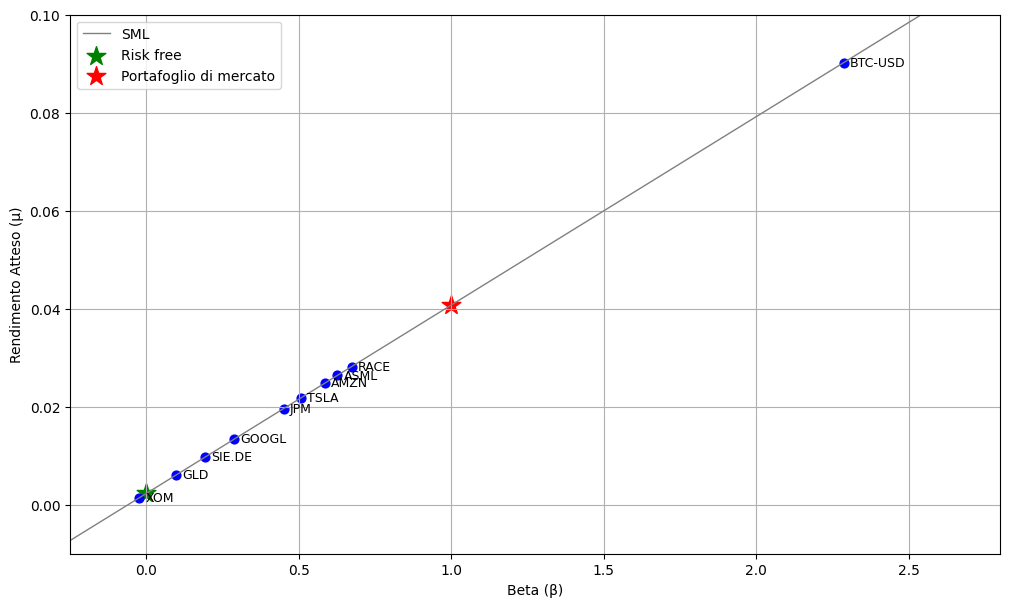

In [12]:
plt.figure(figsize=(12, 7))
plt.plot(x, y, label='SML', color='gray',linewidth=1)

plt.scatter(0,rf,
            color='green',
            marker='*',
            s=200,
            label='Risk free')

plt.scatter(1,mu_tan,
            color='red',
            marker='*',
            s=200,
            label='Portafoglio di mercato')

plt.scatter(betas,
            statistics_df["Expected Return"],
            color='blue',
            s=40)

for i, ticker in enumerate(statistics_df.index):  # Usa statistics_df.index invece di statistics_df["Ticker"]
    beta_i = betas[i]
    mu_i = statistics_df["Expected Return"].iloc[i]
    
    plt.text(beta_i + 0.02,  # piccolo spostamento a destra
             mu_i,           # stessa altezza del punto
             ticker,
             fontsize=9,
             ha='left',
             va='center')

plt.xlabel("Beta (β)")
plt.ylabel("Rendimento Atteso (µ)")
plt.xlim(-0.25, 2.8)
plt.ylim(-0.01, 0.1)
plt.grid(True)
plt.legend()
plt.show()

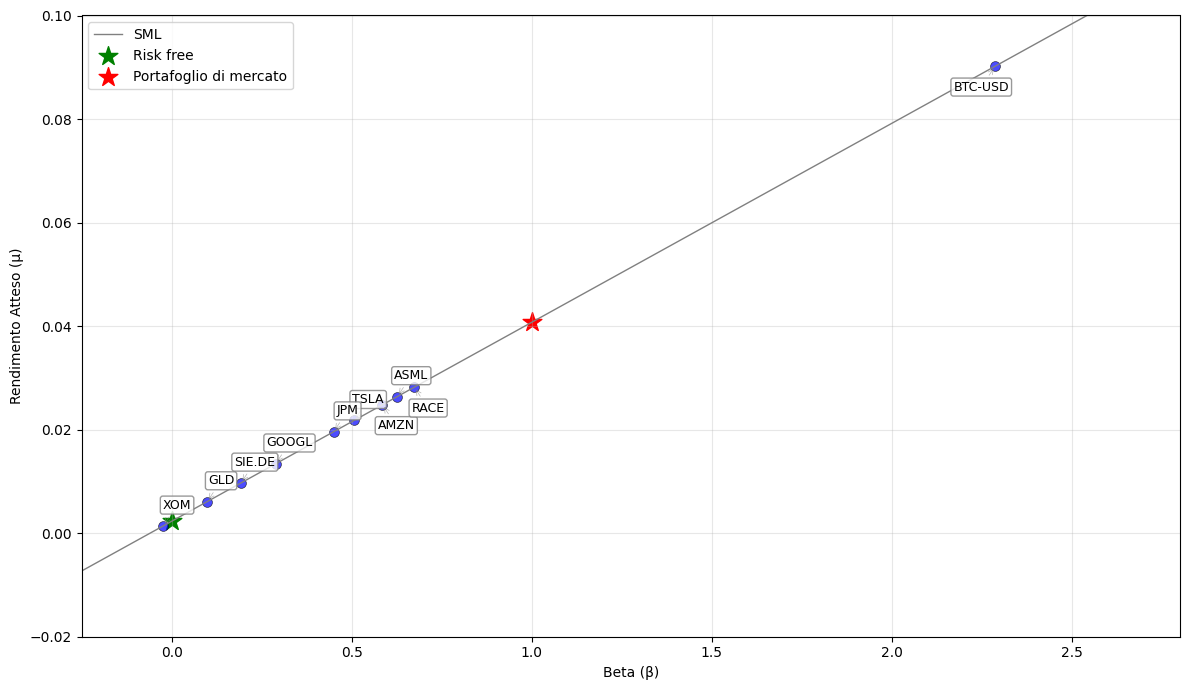

In [13]:
plt.figure(figsize=(12,7))
plt.plot(x, y, label='SML', color='gray', linewidth=1)

plt.scatter(0, rf, color='green', marker='*', s=200, label='Risk free')

plt.scatter(1, mu_tan, color='red', marker='*', s=200, label='Portafoglio di mercato')

plt.scatter(betas, statistics_df["Expected Return"], 
            color='blue', 
            s=50, 
            alpha=0.7, 
            edgecolors='black', 
            linewidth=0.5)

for i, ticker in enumerate(statistics_df.index):
    beta_i = betas[i]
    mu_i = statistics_df["Expected Return"].iloc[i]
    
    if beta_i < 0.5:
        xytext = (10, 15)
    elif beta_i < 1.0:
        xytext = (10, -15) if i % 2 == 0 else (10, 15)
    elif beta_i < 1.5:
        xytext = (-10, 15) if i % 2 == 0 else (10, -15)
    else:
        xytext = (-10, -15)
    
    plt.annotate(ticker,
                xy=(beta_i, mu_i),
                xytext=xytext,
                textcoords='offset points',
                fontsize=9,
                ha='center',
                va='center',
                bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='gray'),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                              color='gray', alpha=0.6, lw=0.5))

plt.xlabel("Beta (β)")
plt.ylabel("Rendimento Atteso (µ)")
plt.xlim(-0.25, 2.8)
plt.ylim(-0.02, 0.1)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

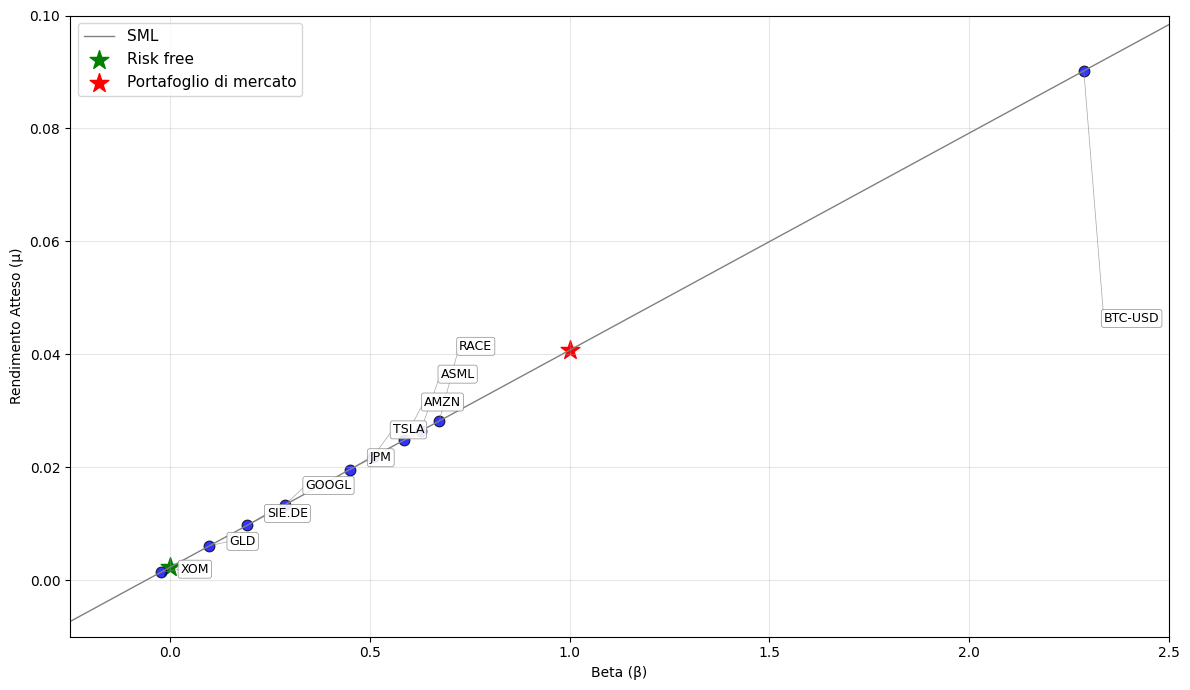

In [14]:
plt.figure(figsize=(12, 7))
plt.plot(x, y, label='SML', color='gray', linewidth=1)
plt.scatter(0, rf, color='green', marker='*', s=200, label='Risk free')
plt.scatter(1, mu_tan, color='red', marker='*', s=200, label='Portafoglio di mercato')
plt.scatter(betas, statistics_df["Expected Return"], 
            color='blue', s=60, alpha=0.8, edgecolors='black', linewidth=0.8)

y_range = statistics_df["Expected Return"].max() - statistics_df["Expected Return"].min()
y_center = statistics_df["Expected Return"].mean()
spacing = y_range / (len(statistics_df) - 1) * 0.8  

sorted_indices = np.argsort(statistics_df["Expected Return"].values)
y_positions = np.linspace(y_center - y_range/2 * 0.5, 
                         y_center + y_range/2 * 0.5, 
                         len(statistics_df))

for i, ticker in enumerate(statistics_df.index):
    beta_i = betas[i]
    mu_i = statistics_df["Expected Return"].iloc[i]
    
    # Trova l'indice ordinato per questa etichetta
    sorted_position = np.where(sorted_indices == i)[0][0]
    label_y = y_positions[sorted_position]
    
    label_x = beta_i + 0.05  
    
    plt.plot([beta_i, label_x], [mu_i, label_y], 
             color='gray', alpha=0.7, linewidth=0.5)
    
    plt.text(label_x, label_y, ticker,
             fontsize=9,
             ha='left',
             va='center',
             bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.9, 
                      edgecolor='gray', linewidth=0.5))

plt.xlabel("Beta (β)")
plt.ylabel("Rendimento Atteso (µ)")
plt.xlim(-0.25, 2.5)  # Ridotto da 3.5 a 3.0
plt.ylim(-0.01, 0.1)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()